In [1]:
h="Hello, \nFucking World"
print(h)

Hello, 
Fucking World


In [2]:
import seaborn as sns

Seaborn has some built-in data sets you can load directly

In [3]:
df=sns.load_dataset('tips')
df1=df.copy

In [4]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [7]:
!pip install ydata_profiling

In [8]:
from ydata_profiling import ProfileReport as pr

In [10]:
profile = pr(df, title="Pandas Profiling Report by SKD",explorative=True)

# Display the report
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 67.13it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

<Axes: xlabel='total_bill', ylabel='Count'>

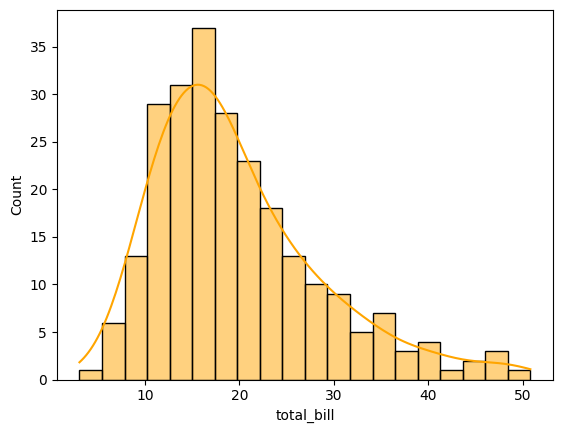

In [16]:
sns.histplot(df['total_bill'],kde=True,color='orange',bins=20)

If you want to castomize the whole thing, use matplotlib, if you want it fast then seaborn

<Axes: ylabel='smoker'>

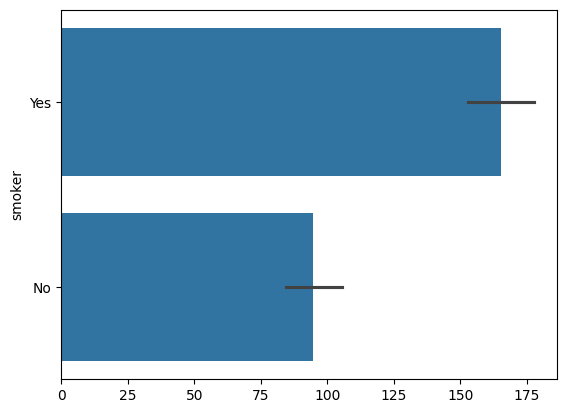

In [18]:
sns.barplot(df['smoker']) # Catagorical column

<Axes: xlabel='day', ylabel='total_bill'>

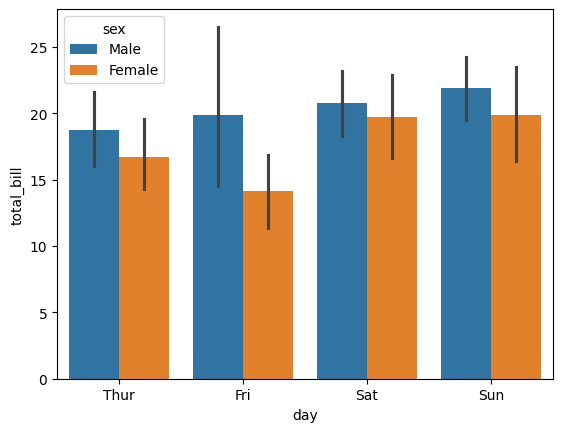

In [22]:
sns.barplot(x='day',y='total_bill',data=df, hue='sex') #catagory, conituous

<Axes: ylabel='day'>

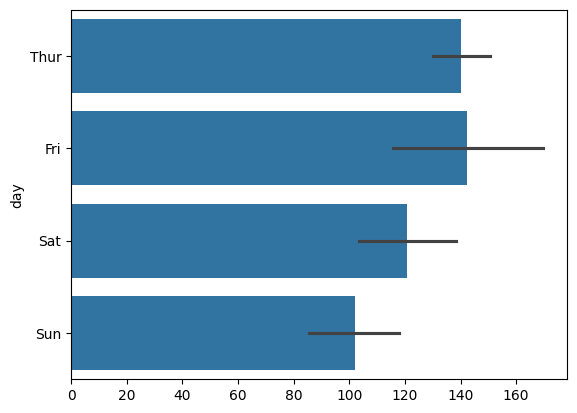

In [21]:
sns.barplot(df['day'])

Boxplot will determine if you have outlier or not

<Axes: xlabel='day', ylabel='total_bill'>

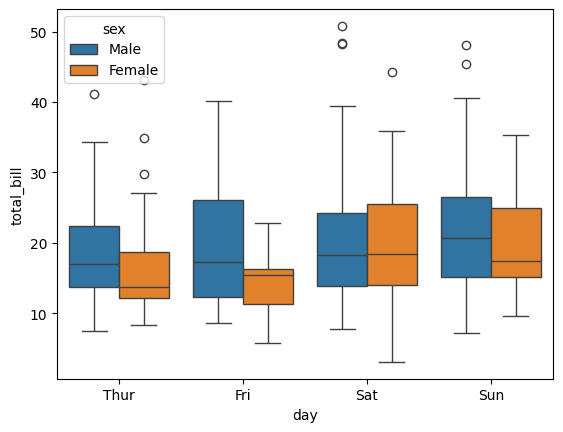

In [23]:
sns.boxplot(x='day',y='total_bill',data=df, hue='sex')

here top bar is the maz, lowest bar is the min... mid bar inside the box is the median and bottop apart of the box is the first quartile and upper one is 2nd quartile

Text(0.5, 1.0, 'Total Bill by Day')

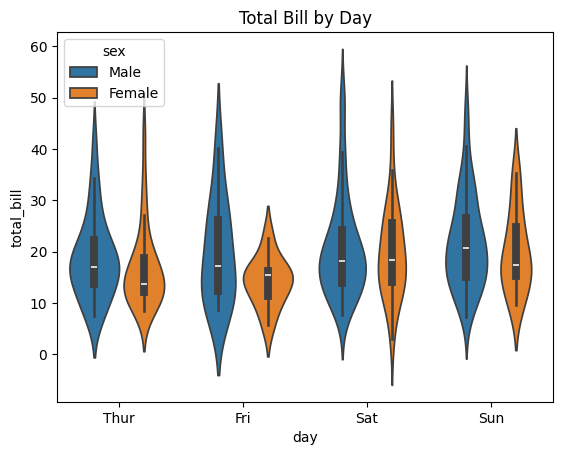

In [25]:
import matplotlib.pyplot as plt
sns.violinplot(x='day',y='total_bill',data=df, hue='sex')
plt.title('Total Bill by Day')

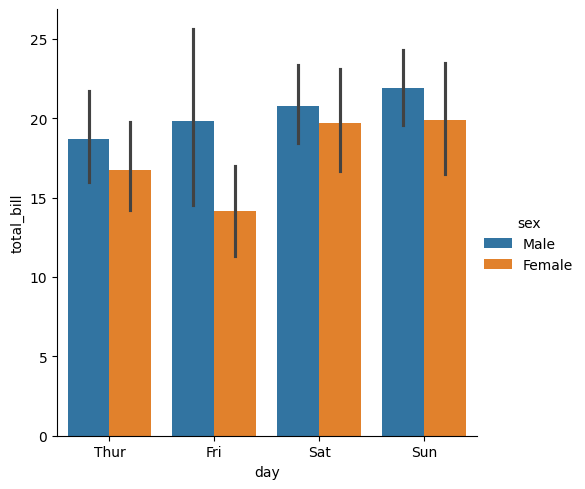

In [26]:
sns.catplot(x='day',y='total_bill',data=df, hue= 'sex', kind='bar')

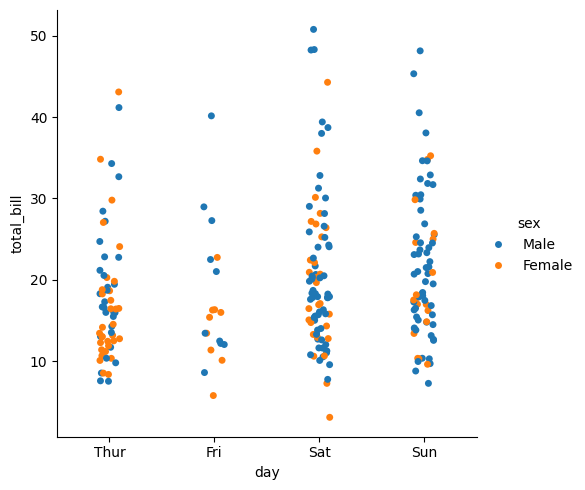

In [28]:
sns.catplot(x='day',y='total_bill',data=df, hue= 'sex', kind='strip')

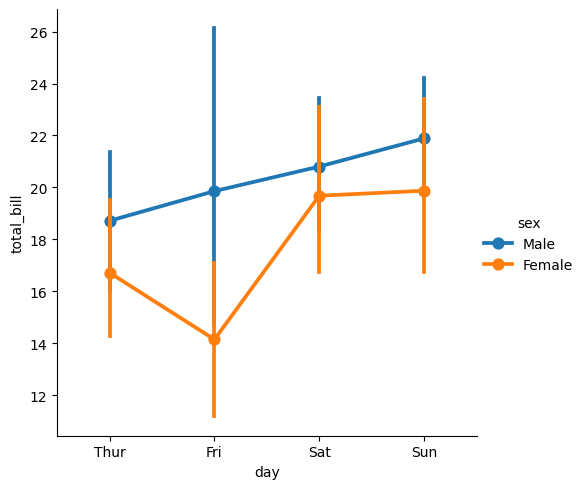

In [29]:
sns.catplot(x='day',y='total_bill',data=df, hue= 'sex', kind='point')

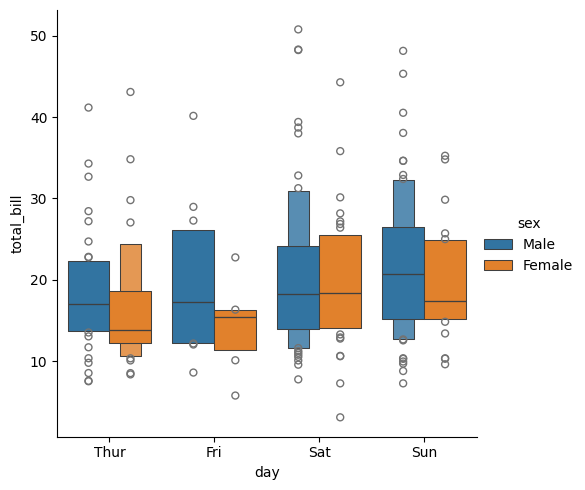

In [31]:
sns.catplot(x='day',y='total_bill',data=df, hue= 'sex', kind='boxen')

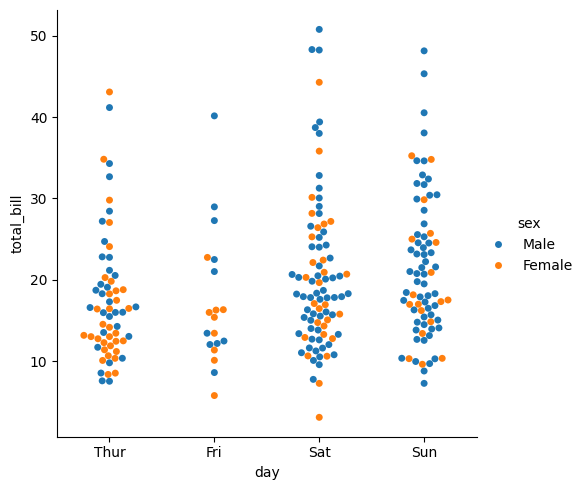

In [32]:
sns.catplot(x='day',y='total_bill',data=df, hue= 'sex', kind='swarm')

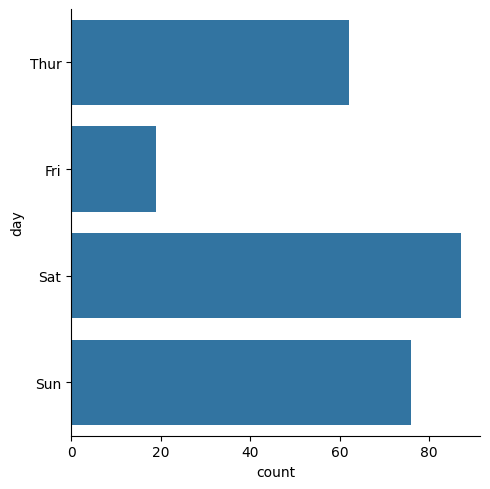

In [36]:
sns.catplot(df['day'], kind='count') #in count plot you just put the catagorical variable not anything else

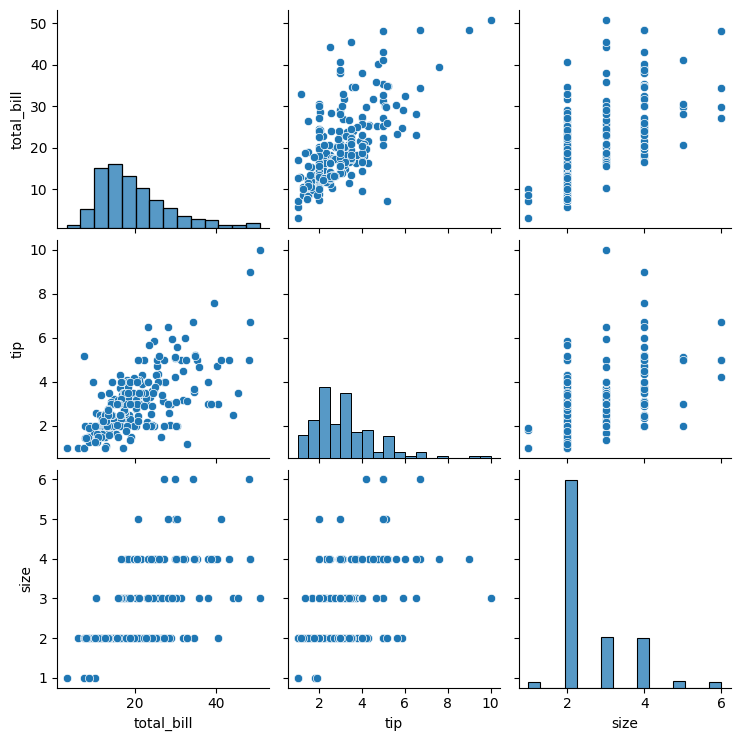

In [37]:
sns.pairplot(df)

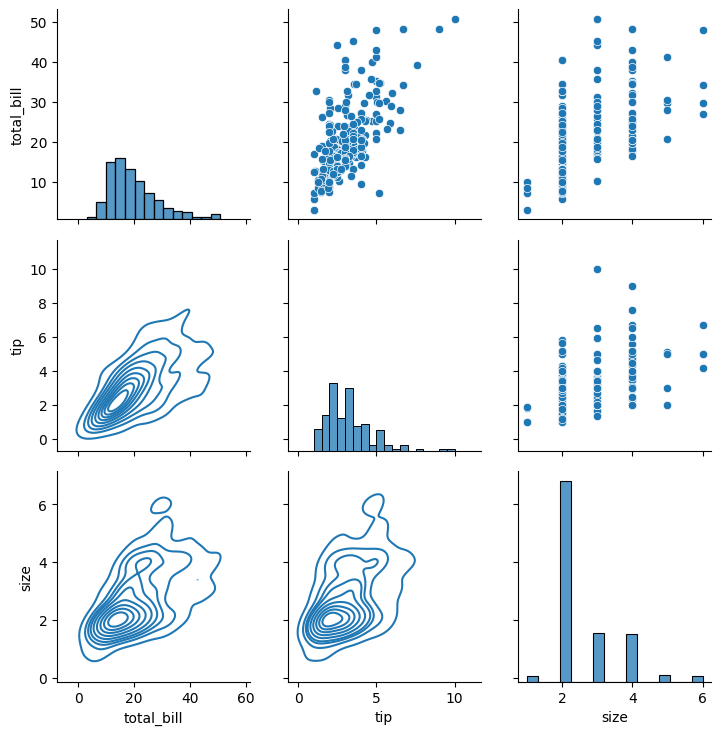

In [41]:
p=sns.PairGrid(df)
p.map_diag(sns.histplot)
p.map_upper(sns.scatterplot)
p.map_lower(sns.kdeplot)

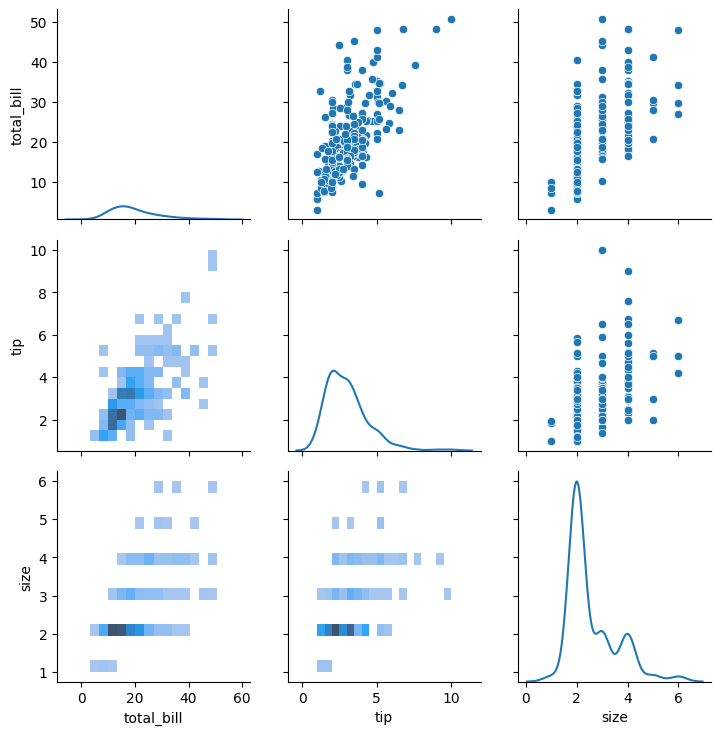

In [42]:
p=sns.PairGrid(df)
p.map_diag(sns.kdeplot)
p.map_upper(sns.scatterplot)
p.map_lower(sns.histplot)

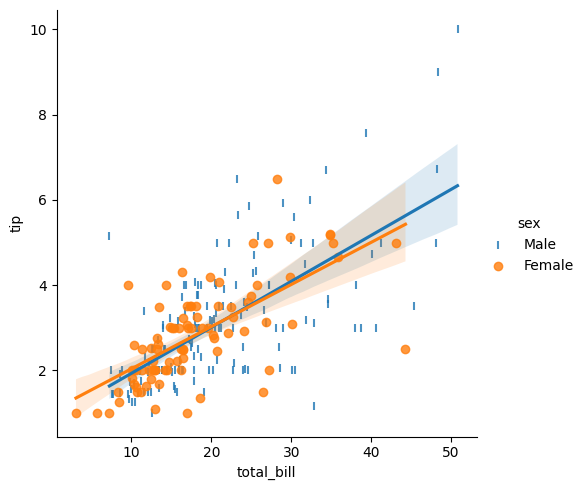

In [46]:
sns.lmplot(x='total_bill',y='tip',data=df, hue='sex', markers=['|','o']) #to have the regressional line

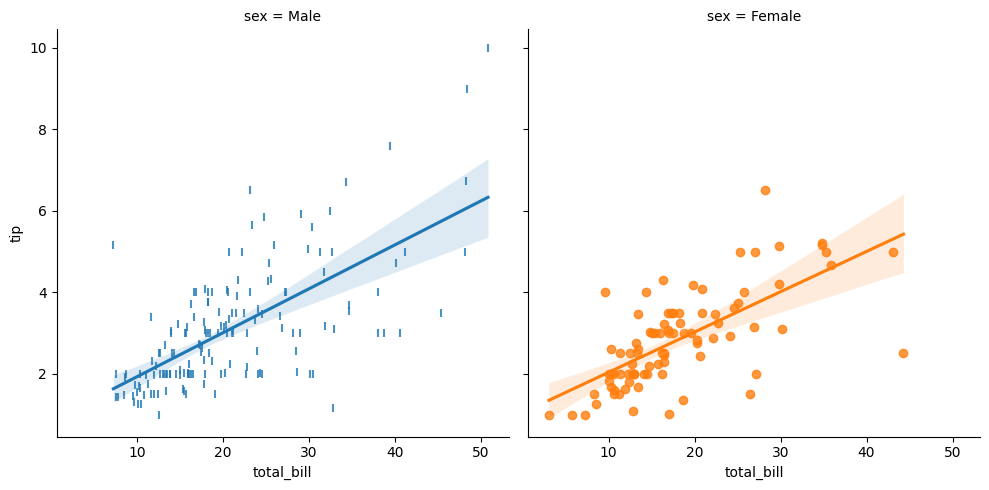

In [48]:
sns.lmplot(x='total_bill',y='tip',data=df, hue='sex', col='sex', markers=['|','o'])
sns.set_style('darkgrid')

In [49]:
import plotly.express as px #

In [54]:
fig=px.pie(df,values='total_bill',names='day',title='Total Bill by Day',hole=0.5)
fig.show()

In [56]:
fig = px.pie(df, values='total_bill', names='day', title='Total Bill by Day', hole=0.5, pulled=[0.2 if day == 'Sun' else 0 for day in df['day'].unique()])
fig.show()

TypeError: pie() got an unexpected keyword argument 'pulled'

In [71]:
pulled_values = [0.2 if day == 'Sun' else 0 for day in df['day']]

fig = px.pie(df, values='total_bill', names='day', title='Total Bill by Day', hole=0.5, pulled=pulled_values)
fig.show()

TypeError: pie() got an unexpected keyword argument 'pulled'

In [72]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Pie(labels=df['day'], values=df['total_bill'], hole=0.5, pull=[0.2 if day == 'Sun' else 0 for day in df['day']])])
fig.update_layout(title_text='Total Bill by Day')
fig.show()

In [60]:
a=df.corr(numeric_only=True)
a

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

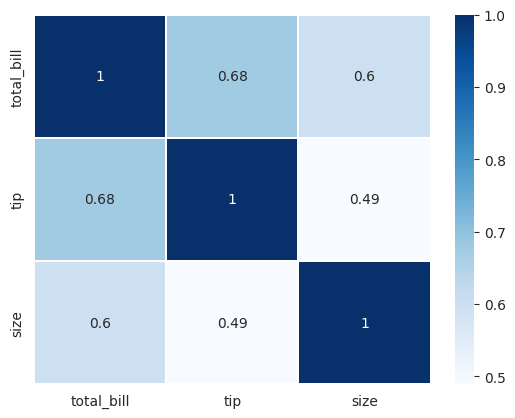

In [69]:
sns.heatmap(a, annot=True, cmap='Blues', linewidth=0.2) #annotation helps you to put values inside the box